# Komplettlauf auswerten (Code-Generierung)

Dieses Notebook wertet den **vollständigen Experiment-Lauf eines Seeds** im Modus
*Code-Generierung* aus: alle vier Modelle x vier Prompt-Strategien x neun Aufgaben x
drei Wiederholungen, plus die regelbasierte Baseline als Referenz.

Kennzahl ist durchgängig die **abgeglichene Genauigkeit** (`acc_aligned`): Bei
stimmendem Schema wird der Anteil korrekt reproduzierter Werte zeilenweise gegen das
Soll gemessen, statt bei leicht abweichender Zeilenzahl hart auf 0 zu fallen.

Transiente API-Fehler (503, Rate-Limit u.a.) werden **nicht** gegen das Modell
gewertet und sind aus allen Mittelwerten ausgeschlossen; sie erscheinen separat in
Abschnitt 7.

In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, "..")
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reporting.analysis import load_runs, heatmap, PROVIDER_LABEL
from reporting import compare

seed = 1
runs = load_runs(seed=seed, include_baseline=True)

llm = runs[runs.provider != "baseline"].copy()          # nur Modell-Laeufe
base = runs[runs.provider == "baseline"].copy()         # regelbasierte Referenz
valid = llm[llm.valid].copy()                           # ohne transiente API-Fehler

for df in (llm, valid):
    df["strategie"] = df.prompt_id.map(compare.STRATEGY_LABELS).fillna(df.prompt_id)
    df["aufgabe"] = df.task_id.map(compare.TASK_LABEL).fillna(df.task_id)

MODELS = [m for m in compare.MODEL_ORDER if m in set(llm.provider)]
LABELS = [PROVIDER_LABEL[m] for m in MODELS]
STRATS = [s for s in compare.STRATEGY_LABELS if s in set(llm.prompt_id)]
STRAT_LABELS = [compare.STRATEGY_LABELS[s] for s in STRATS]
TASKS = compare.task_order(runs)
TASK_LABELS = [compare.TASK_LABEL.get(t, t) for t in TASKS]

print(f"Seed {seed}: {len(llm)} Code-Gen-Laeufe ({len(valid)} gueltig, "
      f"{len(llm) - len(valid)} API-Fehler) + {len(base)} Baseline-Laeufe")
print(f"Modelle: {', '.join(LABELS)}")
print(f"Strategien: {', '.join(STRAT_LABELS)}")
print(f"Grafiken werden gespeichert unter: {compare.FIG_DIR}")

Seed 1: 432 Code-Gen-Laeufe (432 gueltig, 0 API-Fehler) + 9 Baseline-Laeufe
Modelle: Claude, GPT, Gemini, Llama
Strategien: Zero-Shot, Few-Shot, Chain-of-Thought, Schema
Grafiken werden gespeichert unter: C:\Users\geige\Desktop\DHBW\Bachelorarbeit\project\figures


## 1 · Gesamtüberblick

Alle Kennzahlen über den kompletten Lauf. *Erfolgsquote* = Anteil der Läufe, die
lauffähigen Code erzeugt und eine direkt vergleichbare Tabelle geliefert haben;
*Genauigkeit* ist die abgeglichene Genauigkeit über alle gültigen Läufe (echte
Fehlschläge gehen mit ihrem tatsächlichen Wert bzw. 0 ein).

In [2]:
overview = pd.DataFrame({
    "Messung": [
        "Laeufe insgesamt", "Gueltige Laeufe", "API-Fehler (nicht gewertet)",
        "Erfolgsquote", "Genauigkeit (abgeglichen)",
        "Genauigkeit (nur vergleichbare Laeufe)", "Vollstaendigkeit", "Konsistenz",
        "Kosten gesamt ($)", "Prompt-Tokens", "Completion-Tokens",
        "Latenz Oe (s)", "Latenz max (s)",
    ],
    "Wert": [
        len(llm), len(valid), int((~llm.valid).sum()),
        round(valid.produced.mean(), 3),
        round(valid.acc_aligned.mean(), 3),
        round(valid.loc[valid.produced, "accuracy"].mean(), 3),
        round(valid.loc[valid.produced, "completeness"].mean(), 3),
        round(valid.loc[valid.produced, "consistency"].mean(), 3),
        round(llm.cost_usd.sum(), 4),
        int(llm.prompt_tokens.sum()), int(llm.completion_tokens.sum()),
        round(llm.latency_s.mean(), 2), round(llm.latency_s.max(), 2),
    ],
})
overview

,Messung,Wert
0,Laeufe insgesamt,432.0000
1,Gueltige Laeufe,432.0000
2,API-Fehler (nicht gewertet),0.0000
3,Erfolgsquote,0.6250
4,Genauigkeit (abgeglichen),0.5730
5,Genauigkeit (nur vergleichbare Laeufe),0.8920
6,Vollstaendigkeit,1.0000
7,Konsistenz,0.9830
8,Kosten gesamt ($),6.5733
9,Prompt-Tokens,194309.0000


## 2 · Ergebnisse je Aufgabe

Mittel über alle Modelle, Strategien und Wiederholungen. Die Standardabweichung
zeigt, wie stark die Ergebnisse einer Aufgabe je nach Modell/Strategie streuen.

In [3]:
task_summary = (
    valid.groupby(["task_id"])
    .agg(erfolg=("produced", "mean"), acc=("acc_aligned", "mean"),
         std=("acc_aligned", "std"), acc_streng=("acc_streng", "mean"),
         kosten=("cost_usd", "mean"), latenz=("latency_s", "mean"),
         n=("acc_aligned", "size"))
    .reindex(TASKS)
)
task_summary.insert(0, "Aufgabe", TASK_LABELS)
task_summary["baseline"] = [float(base.set_index("task_id").acc_aligned.get(t, np.nan))
                            for t in TASKS]
tab = task_summary.copy()
for c in ["erfolg", "acc", "std", "acc_streng", "baseline"]:
    tab[c] = (tab[c] * 100).round(1)
tab[["Aufgabe", "erfolg", "acc", "std", "acc_streng", "baseline", "kosten", "latenz", "n"]]

,Aufgabe,erfolg,acc,std,acc_streng,baseline,kosten,latenz,n
task_id,,,,,,,,,
cleaning_easy_missing_and_whitespace,Einfach – Leerzeichen & fehlende Werte,81.2,81.2,39.4,81.2,100.0,0.006364,5.838076,48
cleaning_medium_date_formats,Mittel – Datumsformate vereinheitlichen,89.6,85.6,29.6,85.6,100.0,0.015657,11.737135,48
cleaning_hard_semantic_unification,Schwer – ISO-Ländercodes (semantisch),66.7,61.7,44.3,61.7,95.5,0.031820,19.784018,48
dedup_easy_exact_duplicates,Einfach – exakte Duplikate,77.1,77.1,42.5,77.1,100.0,0.004977,4.704629,48
dedup_medium_key_duplicates,Mittel – Schlüssel-Duplikate (E-Mail),41.7,41.6,47.9,39.6,100.0,0.006651,6.231438,48
dedup_hard_fuzzy_duplicates,Schwer – unscharfe Duplikate (Fuzzy),54.2,19.1,29.0,7.5,96.9,0.033419,23.360341,48
transform_easy_type_conversion,Einfach – Typkonvertierung,70.8,68.0,44.3,68.0,100.0,0.009688,7.587189,48
transform_medium_derived_columns,Mittel – abgeleitete Spalten,81.2,81.2,39.4,81.2,100.0,0.006406,5.572901,48
transform_hard_join_and_aggregate,Schwer – Join & Aggregation,0.0,0.0,0.1,0.0,1.5,0.022624,15.943426,48


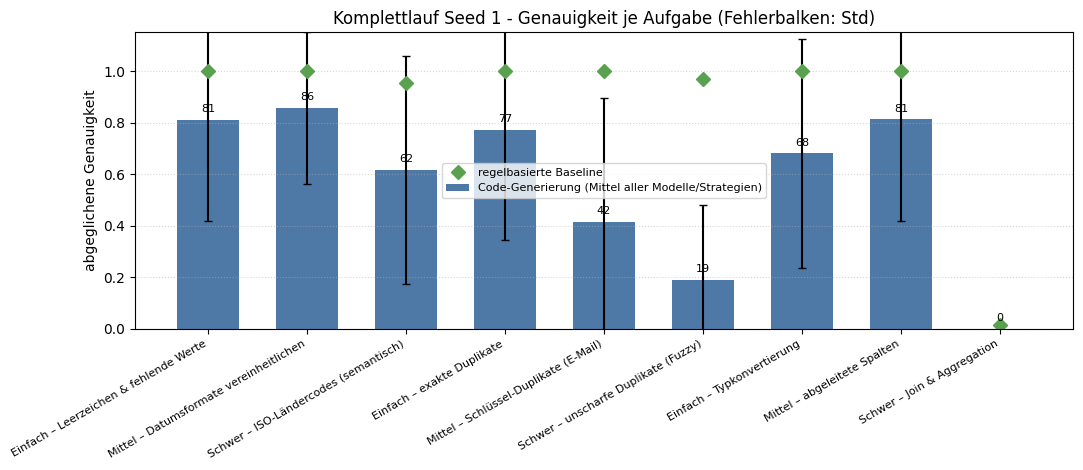

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.8))
x = np.arange(len(TASKS))
ax.bar(x, task_summary.acc, 0.62, yerr=task_summary["std"], capsize=3,
       color=compare.C_CODE, label="Code-Generierung (Mittel aller Modelle/Strategien)")
ax.plot(x, task_summary.baseline, "D", ms=7, color=compare.C_BASE,
        label="regelbasierte Baseline")
for i, v in enumerate(task_summary.acc):
    ax.text(i, v + 0.03, f"{v * 100:.0f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(TASK_LABELS, rotation=30, ha="right", fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_ylabel("abgeglichene Genauigkeit")
ax.set_title(f"Komplettlauf Seed {seed} - Genauigkeit je Aufgabe (Fehlerbalken: Std)")
ax.legend(fontsize=8)
ax.grid(axis="y", ls=":", alpha=0.5)
fig.tight_layout(); compare.save_fig(fig, "lauf_aufgaben"); plt.show()

## 3 · Modelle im Vergleich

Jedes Modell über alle Aufgaben, Strategien und Wiederholungen hinweg.

In [5]:
model_summary = (
    valid.groupby("provider")
    .agg(erfolg=("produced", "mean"), acc=("acc_aligned", "mean"),
         std=("acc_aligned", "std"), kosten_ges=("cost_usd", "sum"),
         kosten_lauf=("cost_usd", "mean"), latenz=("latency_s", "mean"),
         tok_out=("completion_tokens", "mean"), n=("acc_aligned", "size"))
    .reindex(MODELS)
)
model_summary.index = LABELS
mtab = model_summary.copy()
for c in ["erfolg", "acc", "std"]:
    mtab[c] = (mtab[c] * 100).round(1)
mtab.round(4)

,erfolg,acc,std,kosten_ges,kosten_lauf,latenz,tok_out,n
Claude,73.1,66.1,44.7,2.0516,0.0192,10.6032,1153.5047,108
GPT,79.6,73.3,40.6,2.3328,0.0216,13.6437,1377.6481,108
Gemini,71.3,63.5,45.8,2.1889,0.0203,11.5286,2619.0463,108
Llama,25.9,26.1,43.4,0.0000,0.0000,8.9213,255.4907,108


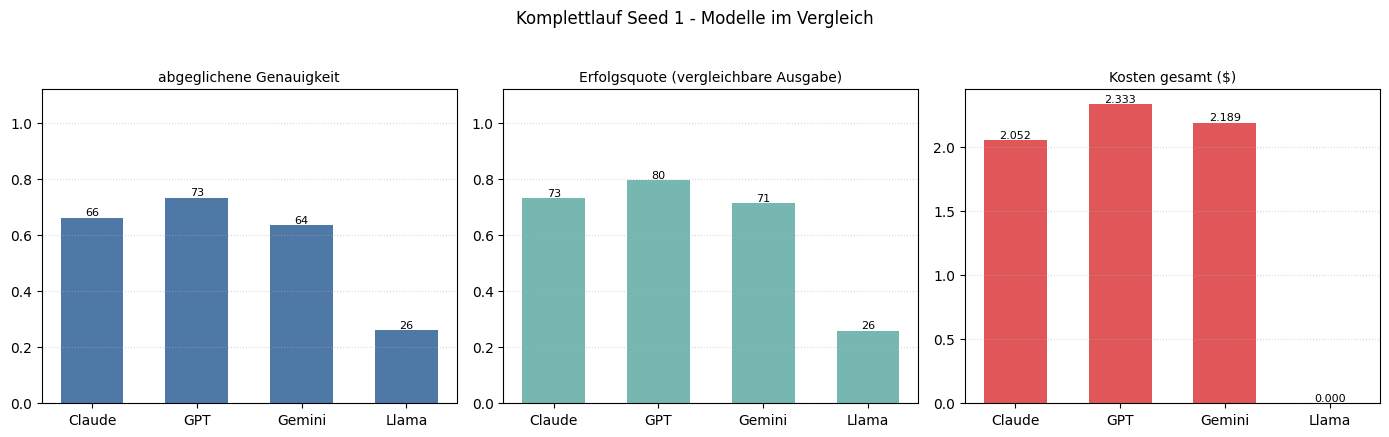

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
x = np.arange(len(LABELS))
specs = [("acc", "abgeglichene Genauigkeit", compare.C_CODE, True),
         ("erfolg", "Erfolgsquote (vergleichbare Ausgabe)", "#76b7b2", True),
         ("kosten_ges", "Kosten gesamt ($)", "#e15759", False)]
for ax, (col, title, color, pct) in zip(axes, specs):
    bars = ax.bar(x, model_summary[col], 0.6, color=color)
    for r in bars:
        h = r.get_height()
        ax.text(r.get_x() + r.get_width() / 2, h, f"{h * 100:.0f}" if pct else f"{h:.3f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(LABELS)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", ls=":", alpha=0.5)
    if pct:
        ax.set_ylim(0, 1.12)
fig.suptitle(f"Komplettlauf Seed {seed} - Modelle im Vergleich", y=1.03)
fig.tight_layout(); compare.save_fig(fig, "lauf_modelle"); plt.show()

## 4 · Prompt-Strategien im Vergleich

Die drei klassischen Strategien (Zero-Shot, Few-Shot, Chain-of-Thought) und die
schema-angereicherte Variante. Letztere wird bewusst getrennt betrachtet, weil sie zu
unnötigen Typkonvertierungen und damit zu Abstürzen verleitet.

In [7]:
strat_summary = (
    valid.groupby("prompt_id")
    .agg(erfolg=("produced", "mean"), acc=("acc_aligned", "mean"),
         std=("acc_aligned", "std"), kosten=("cost_usd", "sum"),
         tok_out=("completion_tokens", "mean"), n=("acc_aligned", "size"))
    .reindex(STRATS)
)
strat_summary.index = STRAT_LABELS
stab = strat_summary.copy()
for c in ["erfolg", "acc", "std"]:
    stab[c] = (stab[c] * 100).round(1)
stab.round(4)

,erfolg,acc,std,kosten,tok_out,n
Zero-Shot,70.4,65.5,45.7,1.5262,1257.3519,108
Few-Shot,64.8,60.9,46.5,1.3666,1087.1852,108
Chain-of-Thought,69.4,64.1,45.7,1.8811,1498.1019,108
Schema,45.4,38.6,46.5,1.7993,1566.8785,108


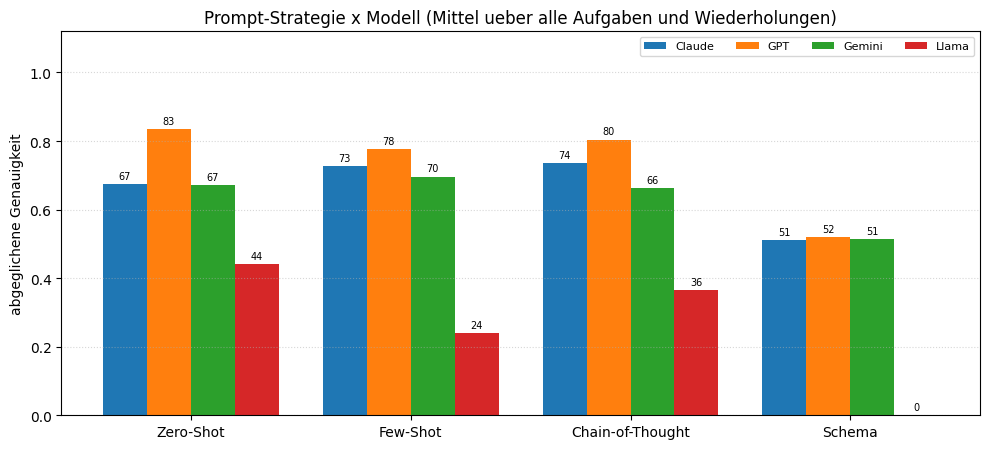

In [8]:
piv = valid.pivot_table(index="prompt_id", columns="provider",
                        values="acc_aligned", aggfunc="mean").reindex(STRATS)[MODELS]
fig, ax = plt.subplots(figsize=(10, 4.6))
x = np.arange(len(STRATS))
w = 0.8 / len(MODELS)
for j, (m, lbl) in enumerate(zip(MODELS, LABELS)):
    off = (j - (len(MODELS) - 1) / 2) * w
    bars = ax.bar(x + off, piv[m], w, label=lbl)
    for r in bars:
        h = r.get_height()
        if not np.isnan(h):
            ax.text(r.get_x() + r.get_width() / 2, h + 0.01, f"{h * 100:.0f}",
                    ha="center", va="bottom", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(STRAT_LABELS)
ax.set_ylim(0, 1.12)
ax.set_ylabel("abgeglichene Genauigkeit")
ax.set_title("Prompt-Strategie x Modell (Mittel ueber alle Aufgaben und Wiederholungen)")
ax.legend(fontsize=8, ncol=len(MODELS))
ax.grid(axis="y", ls=":", alpha=0.5)
fig.tight_layout(); compare.save_fig(fig, "lauf_strategien"); plt.show()

In [9]:
# Strategie x Kategorie - wo lohnt sich welcher Prompt?
cat_piv = valid.pivot_table(index="prompt_id", columns="category",
                            values="acc_aligned", aggfunc="mean").reindex(STRATS)
cat_piv.index = STRAT_LABELS
cat_piv.columns = [compare.CAT_LABEL.get(c, c) for c in cat_piv.columns]
(cat_piv * 100).round(1)

,Datenbereinigung,Duplikaterkennung,Datentransformation
Zero-Shot,89.2,57.7,49.5
Few-Shot,80.0,52.0,50.8
Chain-of-Thought,75.3,59.7,57.5
Schema,60.1,14.3,41.3


## 5 · Heatmaps

Zwei Sichten auf dieselbe Kennzahl: Aufgabe x Modell (über die Strategien gemittelt)
und Aufgabe x Strategie (über die Modelle gemittelt).

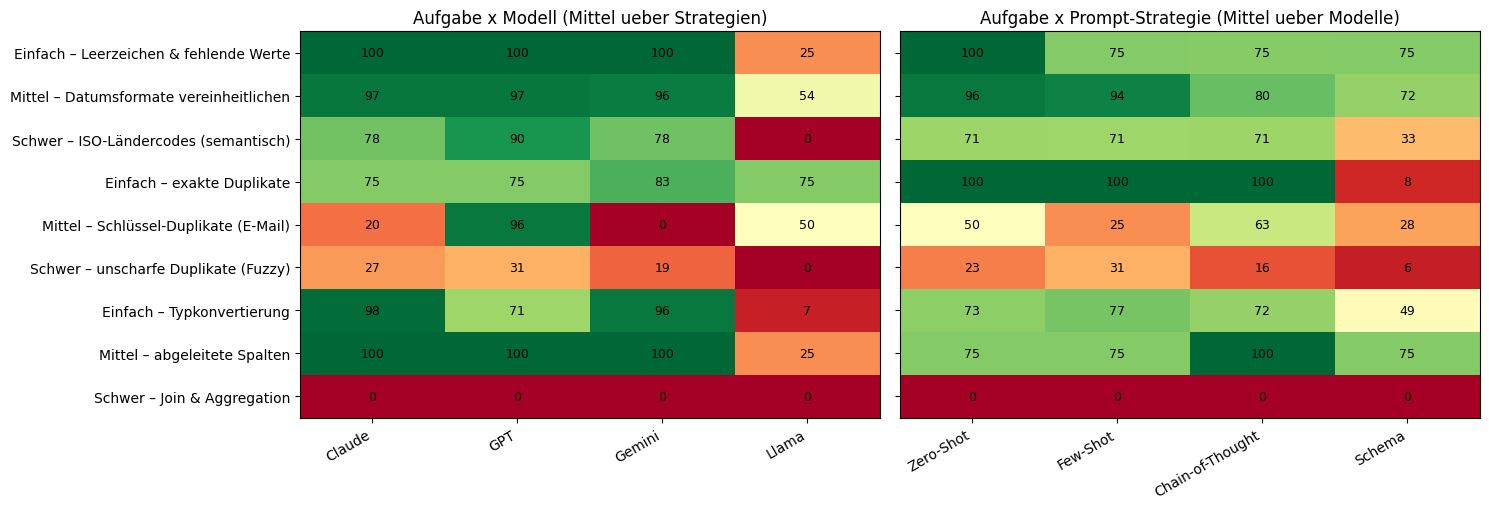

In [10]:
h1 = valid.pivot_table(index="task_id", columns="provider",
                       values="acc_aligned", aggfunc="mean").reindex(TASKS)[MODELS]
h1.index, h1.columns = TASK_LABELS, LABELS
h2 = valid.pivot_table(index="task_id", columns="prompt_id",
                       values="acc_aligned", aggfunc="mean").reindex(TASKS)[STRATS]
h2.index, h2.columns = TASK_LABELS, STRAT_LABELS

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
heatmap(h1, ax=axes[0], title="Aufgabe x Modell (Mittel ueber Strategien)")
heatmap(h2, ax=axes[1], title="Aufgabe x Prompt-Strategie (Mittel ueber Modelle)")
axes[1].set_yticklabels([])
fig.tight_layout(); compare.save_fig(fig, "lauf_heatmaps"); plt.show()

## 6 · Reproduzierbarkeit (FF3)

Streuung der Genauigkeit über die drei Wiederholungen **derselben** Konfiguration
(Aufgabe x Modell x Strategie). Eine Standardabweichung nahe 0 bedeutet: Das Modell
liefert bei identischem Prompt stabil dasselbe Ergebnis.

In [11]:
rep = (valid.groupby(["task_id", "provider", "prompt_id"])
       .agg(acc=("acc_aligned", "mean"), std=("acc_aligned", "std"),
            n=("acc_aligned", "size")))
rep = rep[rep.n > 1]
print(f"Konfigurationen mit >1 Wiederholung: {len(rep)}")
print(f"Mittlere Streuung ueber Wiederholungen: {rep['std'].mean() * 100:.2f} Prozentpunkte")
print(f"Anteil vollstaendig stabiler Konfigurationen (Std = 0): "
      f"{(rep['std'] < 1e-9).mean() * 100:.1f} %")

instabil = rep.sort_values("std", ascending=False).head(12).reset_index()
instabil["Aufgabe"] = instabil.task_id.map(compare.TASK_LABEL)
instabil["Modell"] = instabil.provider.map(PROVIDER_LABEL)
instabil["Strategie"] = instabil.prompt_id.map(compare.STRATEGY_LABELS)
instabil["acc %"] = (instabil.acc * 100).round(1)
instabil["std %"] = (instabil["std"] * 100).round(1)
instabil[["Aufgabe", "Modell", "Strategie", "acc %", "std %"]]

Konfigurationen mit >1 Wiederholung: 144
Mittlere Streuung ueber Wiederholungen: 4.07 Prozentpunkte
Anteil vollstaendig stabiler Konfigurationen (Std = 0): 74.3 %


,Aufgabe,Modell,Strategie,acc %,std %
0,Einfach – exakte Duplikate,Gemini,Schema,33.3,57.7
1,Mittel – Datumsformate vereinheitlichen,Llama,Chain-of-Thought,29.7,51.4
2,Mittel – Schlüssel-Duplikate (E-Mail),Claude,Schema,28.3,49.0
3,Schwer – unscharfe Duplikate (Fuzzy),Claude,Few-Shot,69.4,48.0
4,Schwer – unscharfe Duplikate (Fuzzy),Gemini,Few-Shot,41.5,47.7
5,Schwer – ISO-Ländercodes (semantisch),Gemini,Schema,26.8,46.3
6,Einfach – Typkonvertierung,Llama,Few-Shot,26.7,46.2
7,Mittel – Schlüssel-Duplikate (E-Mail),Claude,Chain-of-Thought,53.3,46.2
8,Schwer – ISO-Ländercodes (semantisch),Claude,Schema,26.1,45.2
9,Schwer – unscharfe Duplikate (Fuzzy),GPT,Zero-Shot,64.3,44.2


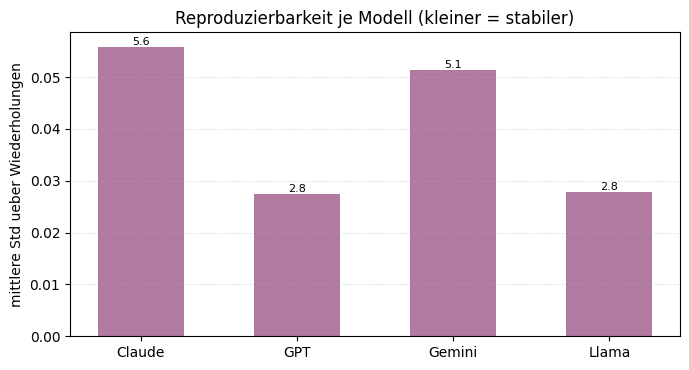

In [12]:
rep_model = (valid.groupby(["task_id", "provider", "prompt_id"])["acc_aligned"]
             .std().groupby("provider").mean().reindex(MODELS))
fig, ax = plt.subplots(figsize=(7, 3.8))
bars = ax.bar(LABELS, rep_model.values, 0.55, color="#b07aa1")
for r in bars:
    h = r.get_height()
    ax.text(r.get_x() + r.get_width() / 2, h, f"{h * 100:.1f}", ha="center",
            va="bottom", fontsize=8)
ax.set_ylabel("mittlere Std ueber Wiederholungen")
ax.set_title("Reproduzierbarkeit je Modell (kleiner = stabiler)")
ax.grid(axis="y", ls=":", alpha=0.5)
fig.tight_layout(); compare.save_fig(fig, "lauf_reproduzierbarkeit"); plt.show()

## 7 · Fehleranalyse

`ok` = vergleichbare Tabelle geliefert, `code_error` = erzeugter Code stürzt ab,
`wrong_output` = Code läuft, liefert aber falsches Schema oder falsche Zeilenzahl,
`api_error` = transienter Anbieterfehler (nicht gegen das Modell gewertet).

status,ok,code_error,wrong_output,api_error
Claude,79,24,5,0
GPT,86,11,11,0
Gemini,77,25,6,0
Llama,28,74,6,0


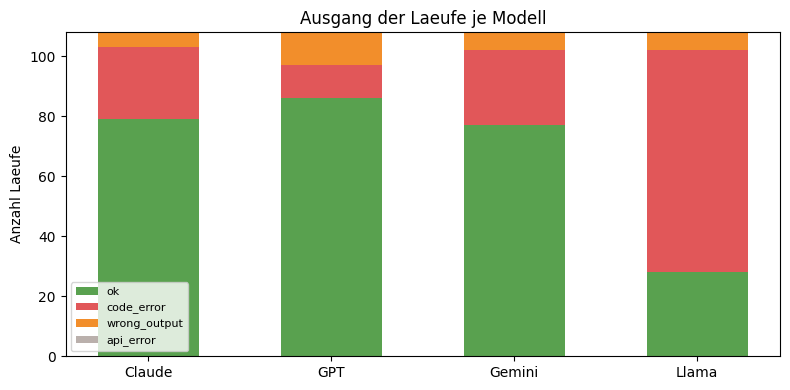

In [13]:
status_tab = pd.crosstab(llm.provider, llm.status).reindex(MODELS)
status_tab.index = LABELS
for c in ["ok", "code_error", "wrong_output", "api_error"]:
    if c not in status_tab.columns:
        status_tab[c] = 0
status_tab = status_tab[["ok", "code_error", "wrong_output", "api_error"]]
display(status_tab)

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(status_tab))
for col, color in zip(["ok", "code_error", "wrong_output", "api_error"],
                      ["#59a14f", "#e15759", "#f28e2b", "#bab0ac"]):
    ax.bar(status_tab.index, status_tab[col], 0.55, bottom=bottom, label=col, color=color)
    bottom += status_tab[col].values
ax.set_ylabel("Anzahl Laeufe")
ax.set_title("Ausgang der Laeufe je Modell")
ax.legend(fontsize=8)
fig.tight_layout(); compare.save_fig(fig, "lauf_fehler"); plt.show()

In [14]:
# Echte Fehlschlaege (Modellschwaeche) im Detail
fehler = valid[~valid.produced].copy()
fehler["Modell"] = fehler.provider.map(PROVIDER_LABEL)
fehler["Strategie"] = fehler.prompt_id.map(compare.STRATEGY_LABELS)
fehler["Grund"] = fehler.status.map({"code_error": "Code stuerzt ab",
                                     "wrong_output": "falsches Schema/Zeilenzahl"})
print(f"{len(fehler)} echte Fehlschlaege von {len(valid)} gueltigen Laeufen "
      f"({len(fehler) / len(valid) * 100:.1f} %)")
display(pd.crosstab(fehler.aufgabe, fehler.Grund))
fehler[["aufgabe", "Modell", "Strategie", "repetition", "Grund", "acc_aligned"]] \
    .sort_values(["aufgabe", "Modell"]).head(30)

162 echte Fehlschlaege von 432 gueltigen Laeufen (37.5 %)


Grund,Code stuerzt ab,falsches Schema/Zeilenzahl
aufgabe,,
Einfach – Leerzeichen & fehlende Werte,9,0
Einfach – Typkonvertierung,14,0
Einfach – exakte Duplikate,11,0
Mittel – Datumsformate vereinheitlichen,3,2
Mittel – Schlüssel-Duplikate (E-Mail),27,1
Mittel – abgeleitete Spalten,9,0
Schwer – ISO-Ländercodes (semantisch),12,4
Schwer – Join & Aggregation,33,15
Schwer – unscharfe Duplikate (Fuzzy),16,6


,aufgabe,Modell,Strategie,repetition,Grund,acc_aligned
41,Einfach – Leerzeichen & fehlende Werte,Llama,Few-Shot,1,Code stuerzt ab,0.0
42,Einfach – Leerzeichen & fehlende Werte,Llama,Few-Shot,2,Code stuerzt ab,0.0
43,Einfach – Leerzeichen & fehlende Werte,Llama,Few-Shot,3,Code stuerzt ab,0.0
44,Einfach – Leerzeichen & fehlende Werte,Llama,Chain-of-Thought,1,Code stuerzt ab,0.0
45,Einfach – Leerzeichen & fehlende Werte,Llama,Chain-of-Thought,2,Code stuerzt ab,0.0
46,Einfach – Leerzeichen & fehlende Werte,Llama,Chain-of-Thought,3,Code stuerzt ab,0.0
47,Einfach – Leerzeichen & fehlende Werte,Llama,Schema,1,Code stuerzt ab,0.0
48,Einfach – Leerzeichen & fehlende Werte,Llama,Schema,2,Code stuerzt ab,0.0
49,Einfach – Leerzeichen & fehlende Werte,Llama,Schema,3,Code stuerzt ab,0.0
449,Einfach – Typkonvertierung,GPT,Schema,1,Code stuerzt ab,0.0


In [15]:
# Transiente API-Fehler: welche Konfigurationen sollten nachgelaufen werden?
api = llm[llm.status == "api_error"]
if len(api):
    a = api.copy()
    a["Modell"] = a.provider.map(PROVIDER_LABEL)
    display(a[["task_id", "Modell", "prompt_id", "repetition", "error"]])
    print("Nachlaufen:")
    print("  python scripts/run_experiments.py --providers "
          f"{' '.join(sorted(api.provider.unique()))} --tasks "
          f"{' '.join(sorted(api.task_id.unique()))}")
else:
    print("Keine transienten API-Fehler im Lauf.")

Keine transienten API-Fehler im Lauf.


## 8 · Effizienz: Kosten, Tokens, Latenz

Genauigkeit ist nur die halbe Miete – für die Handlungsempfehlung zählt, was ein
Ergebnis kostet und wie lange es dauert.

,kosten_ges,kosten_lauf,tok_in,tok_out,latenz,latenz_max,acc
Claude,2.0516,0.0192,66737.0,123425.0,10.6032,47.5575,66.1
GPT,2.3328,0.0216,40425.0,148786.0,13.6437,42.9990,73.3
Gemini,2.1889,0.0203,44967.0,282857.0,11.5286,40.6010,63.5
Llama,0.0000,0.0000,42180.0,27593.0,8.9213,22.9292,26.1


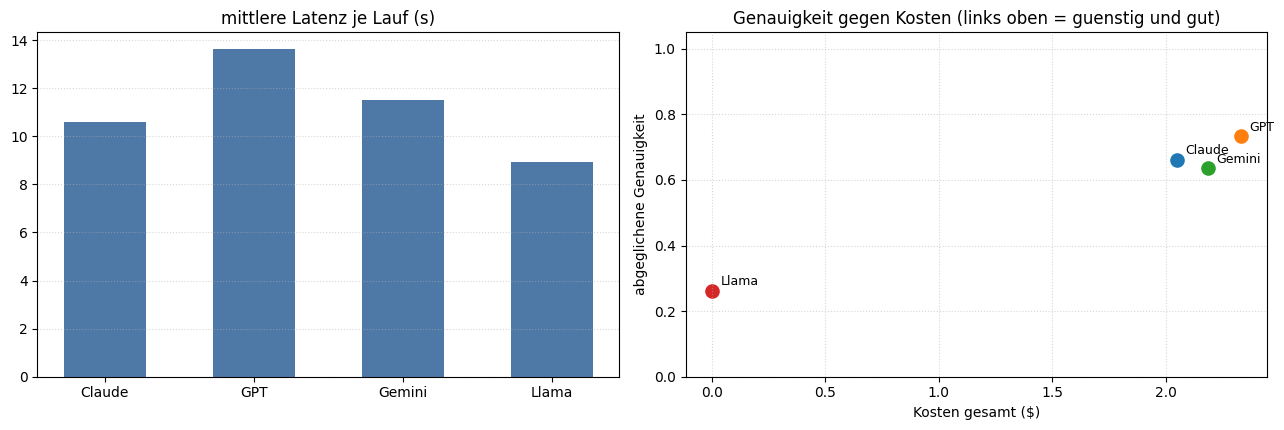

In [16]:
eff = (llm.groupby("provider")
       .agg(kosten_ges=("cost_usd", "sum"), kosten_lauf=("cost_usd", "mean"),
            tok_in=("prompt_tokens", "sum"), tok_out=("completion_tokens", "sum"),
            latenz=("latency_s", "mean"), latenz_max=("latency_s", "max"))
       .reindex(MODELS))
eff.index = LABELS
eff["acc"] = (model_summary["acc"] * 100).round(1)
display(eff.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].bar(LABELS, eff.latenz, 0.55, color="#4e79a7")
axes[0].set_title("mittlere Latenz je Lauf (s)")
axes[0].grid(axis="y", ls=":", alpha=0.5)
for i, (c, a, l) in enumerate(zip(eff.kosten_ges, model_summary["acc"], LABELS)):
    axes[1].scatter(c, a, s=90, color=f"C{i}")
    axes[1].annotate(l, (c, a), textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[1].set_xlabel("Kosten gesamt ($)")
axes[1].set_ylabel("abgeglichene Genauigkeit")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Genauigkeit gegen Kosten (links oben = guenstig und gut)")
axes[1].grid(ls=":", alpha=0.5)
fig.tight_layout(); compare.save_fig(fig, "lauf_effizienz"); plt.show()

## 9 · Vergleich mit der regelbasierten Baseline

Gegenübergestellt werden je Aufgabe die **beste klassische Prompt-Strategie** (so
schneidet ein Modell mit gut gewähltem Prompt ab) und die regelbasierte Baseline.
Positive Differenzen bedeuten: die Code-Generierung schlägt das regelbasierte
Verfahren.

In [17]:
cg = compare.codegen_matrix(runs).reindex(TASKS)[MODELS]
bl = compare.baseline_series(runs)
cmp_tab = pd.DataFrame({
    "Aufgabe": TASK_LABELS,
    "Code-Gen best (Ø Modelle)": cg.mean(axis=1).values,
    "Code-Gen bestes Modell": cg.max(axis=1).values,
    "Baseline": [float(bl.get(t, np.nan)) for t in TASKS],
})
cmp_tab["Delta bestes Modell"] = cmp_tab["Code-Gen bestes Modell"] - cmp_tab["Baseline"]
num = cmp_tab.columns[1:]
cmp_tab[num] = (cmp_tab[num] * 100).round(1)
cmp_tab

,Aufgabe,Code-Gen best (Ø Modelle),Code-Gen bestes Modell,Baseline,Delta bestes Modell
0,Einfach – Leerzeichen & fehlende Werte,100.0,100.0,100.0,0.0
1,Mittel – Datumsformate vereinheitlichen,96.4,96.5,100.0,-3.5
2,Schwer – ISO-Ländercodes (semantisch),71.5,95.8,95.5,0.3
3,Einfach – exakte Duplikate,100.0,100.0,100.0,0.0
4,Mittel – Schlüssel-Duplikate (E-Mail),63.3,100.0,100.0,0.0
5,Schwer – unscharfe Duplikate (Fuzzy),43.8,69.4,96.9,-27.5
6,Einfach – Typkonvertierung,80.1,100.0,100.0,0.0
7,Mittel – abgeleitete Spalten,100.0,100.0,100.0,0.0
8,Schwer – Join & Aggregation,0.1,0.2,1.5,-1.3


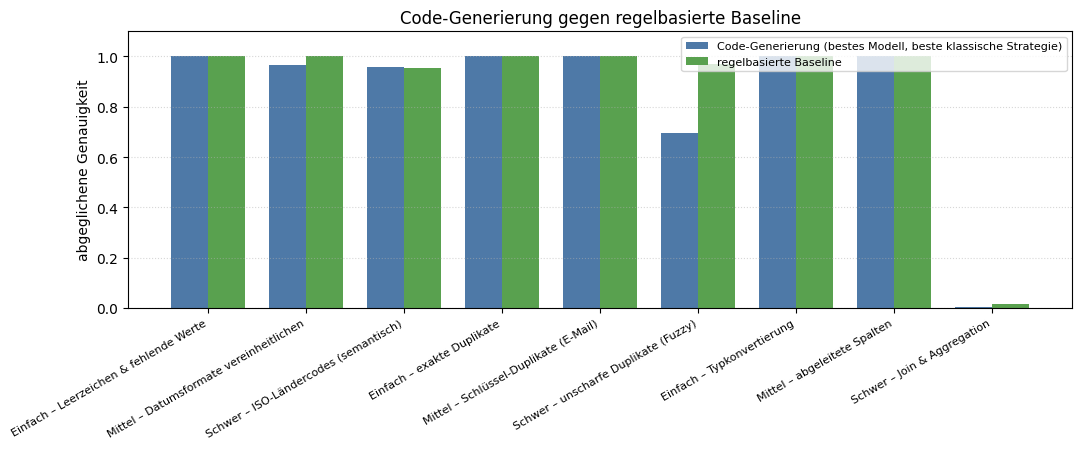

In [18]:
fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(TASKS))
w = 0.38
ax.bar(x - w / 2, cg.max(axis=1).values, w, color=compare.C_CODE,
       label="Code-Generierung (bestes Modell, beste klassische Strategie)")
ax.bar(x + w / 2, [float(bl.get(t, np.nan)) for t in TASKS], w,
       color=compare.C_BASE, label="regelbasierte Baseline")
ax.set_xticks(x); ax.set_xticklabels(TASK_LABELS, rotation=30, ha="right", fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel("abgeglichene Genauigkeit")
ax.set_title("Code-Generierung gegen regelbasierte Baseline")
ax.legend(fontsize=8)
ax.grid(axis="y", ls=":", alpha=0.5)
fig.tight_layout(); compare.save_fig(fig, "lauf_baseline"); plt.show()

## 10 · Textreport und CSV-Export

Der Konsolen-Report aus `scripts/analyze_results.py` – identische Zahlen, kompakt zum
Mitschreiben. `write_csv=True` legt zusätzlich `data/results/<seed>/analysis/runs.csv`
mit allen Einzelläufen ab.

In [19]:
from scripts import analyze_results
analyze_results.analyze(seed=seed, write_csv=True)

AUSWERTUNG  Seed 1   |   432 Läufe   |   Modell(e): claude-sonnet-5, gemini-3.6-flash, gpt-5.6-terra, llama3.1

# GESAMT   (432 gültige Läufe; 0 API-Fehler ausgeschlossen)
  Erfolgsquote (lauffähig & bewertbar):  62.5% (270/432)
  Genauigkeit effektiv (abgeglichen)  :  57.3%
  Genauigkeit nur bewertbare Läufe    :  89.2%
  Kosten gesamt                       : $6.5733
  Tokens  in / out                    : 194,309 / 582,661
  Latenz Ø / max                      : 11.2s / 47.6s

# JE AUFGABE  (acc = abgeglichene Genauigkeit, ±Std über Wiederholungen)
  Aufgabe                                   Erfolg   acc Ø   ±Std       $Ø
  cleaning_easy_missing_and_whitespace       81.2%   81.2%  39.0% $ 0.0064
  cleaning_medium_date_formats               89.6%   85.6%  29.2% $ 0.0157
  cleaning_hard_semantic_unification         66.7%   61.7%  43.9% $ 0.0318
  dedup_easy_exact_duplicates                77.1%   77.1%  42.0% $ 0.0050
  transform_easy_type_conversion             70.8%   68.0%  43.8% $ 

## 11 · Kernaussagen des Laufs (Seed 1)

- **Gesamtbild:** 432 Code-Gen-Läufe, davon 62,5 % mit direkt vergleichbarer Ausgabe;
  mittlere abgeglichene Genauigkeit 57,3 % bei 6,57 $ Gesamtkosten. In diesem Lauf
  traten **keine transienten API-Fehler** auf – alle Fehlschläge sind dem Modell
  zuzurechnen.
- **Modelle:** GPT liegt vorn (73,3 % Genauigkeit, 79,6 % Erfolgsquote), gefolgt von
  Claude (66,1 %) und Gemini (63,5 %). Das lokale Llama fällt mit 26,1 % deutlich ab –
  es verursacht zwar keine Kosten, scheitert aber in 74 von 108 Läufen schon an
  lauffähigem Code.
- **Fehlerbild:** 134 Abstürze gegenüber nur 28 inhaltlich falschen Tabellen. Das
  dominierende Problem der Code-Generierung ist damit nicht fehlerhafte Logik, sondern
  **nicht ausführbarer Code** – ein Befund, der für Retry-/Repair-Schleifen in der
  Pipeline spricht.
- **Prompt-Strategie:** Zero-Shot ist im Mittel am stärksten (65,5 %), vor
  Chain-of-Thought (64,1 %) und Few-Shot (60,9 %). Die schema-angereicherte Variante
  fällt mit 38,6 % klar ab und bricht bei der Duplikaterkennung auf 14,3 % ein: Das
  mitgelieferte Schema verleitet zu unnötigen, abstürzenden Typkonvertierungen.
  Kategorieabhängig kehrt sich die Rangfolge um – Datenbereinigung profitiert von
  Zero-Shot (89,2 %), Datentransformation von Chain-of-Thought (57,5 %).
- **Aufgaben:** Die einfachen und mittleren Bereinigungsaufgaben liegen über 81 %,
  während *unscharfe Duplikate* (19,1 %) und *Join & Aggregation* (0 %) die Grenzen
  markieren. Der Nullwert bei Join & Aggregation ist ein **Metrik-Artefakt** (die
  Aggregat-Tabelle besitzt keinen eindeutigen Zeilenschlüssel und fällt daher hart
  durch) – auch die regelbasierte Baseline erreicht dort nur 1,5 %.
- **Reproduzierbarkeit (FF3):** Die mittlere Streuung über drei Wiederholungen liegt
  bei 4,1 Prozentpunkten, 74,3 % aller Konfigurationen sind vollständig stabil.
  Instabilität konzentriert sich auf die Schema-Variante und die unscharfen Duplikate –
  also genau dort, wo das Modell freie Entscheidungsspielräume hat.
- **Gegen die Baseline:** Bei sechs von neun Aufgaben erreicht die Code-Generierung
  mit gut gewähltem Prompt Baseline-Niveau. Der einzige deutliche Rückstand sind die
  unscharfen Duplikate (−27,5 Prozentpunkte); dort ist die Direkt-Verarbeitung der
  stärkere Ansatz (siehe `inspect_overview.ipynb`).